In [1]:
!pip install -q torch torchvision tqdm scikit-learn seaborn Pillow


In [2]:
import os, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, ConfusionMatrixDisplay, accuracy_score)
warnings.filterwarnings('ignore')
torch.manual_seed(42)

In [3]:
#Early config for throughout the code 
#local directories
mangroveDir = Path(r'C:\Users\FSOS\Music\zow\man')           
nonmangroveDir = Path(r'C:\Users\FSOS\Music\zow\non')           
tilledMangroveDir = Path(r'C:\Users\FSOS\Music\zow\manTiled')      
tilledNonmangroveDir = Path(r'C:\Users\FSOS\Music\zow\nonmanTiled')  
bestMSaved = 'bestBinary.pth'
GPU = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
imageType = {'.jpg', '.jpeg', '.png'}


In [4]:
mangroveImage = sorted(file for file in mangroveDir.rglob('*')  if file.suffix.lower() in imageType)
nonmangroveImage = sorted(file for file in nonmangroveDir.rglob('*') if file.suffix.lower() in imageType)
ratio = len(mangroveImage) / max(len(nonmangroveImage), 1) #ratio of mangrove to nonmangrove
if ratio < 0.5 or ratio > 2.0:
    print('There is an imbalance')
    print(f'Mangrove: {len(mangroveImage)}, Non-mangrove: {len(nonmangroveImage)}, Ratio: {ratio:.2f}')

There is an imbalance
Mangrove: 622, Non-mangrove: 19591, Ratio: 0.03


In [5]:
def split_image_to_tiles(img_path: Path, out_dir: Path,tile_size: int = 512,min_valid_frac: float = 0.10) -> int:
    try:
        img = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f'  [SKIP] {img_path.name}: {e}')
        return 0

    W, H  = img.size
    n_cols = max(1, W // tile_size)
    n_rows = max(1, H // tile_size)
    saved  = 0
    for r in range(n_rows):
        for c in range(n_cols):
            left, upper = c * tile_size, r * tile_size
            right = min(left + tile_size, W)
            lower = min(upper + tile_size, H)
            tile  = img.crop((left, upper, right, lower))
            if tile.size != (tile_size, tile_size):
                padded = Image.new('RGB', (tile_size, tile_size), (0, 0, 0))
                padded.paste(tile, (0, 0))
                tile = padded

            arr = np.array(tile, dtype=np.float32)
            if np.any(arr > 5, axis=-1).mean() < min_valid_frac:
                continue   # skip near-black tile

            out_name = f'{img_path.stem}_r{r:03d}_c{c:03d}.jpg'
            tile.save(out_dir / out_name, 'JPEG', quality=95)
            saved += 1
    return saved

In [6]:
def run_tiling(src_dir: Path, dst_dir: Path, tile_size: int = 512) -> int:
    dst_dir.mkdir(parents=True, exist_ok=True)
    images = [p for p in src_dir.rglob('*') if p.suffix.lower() in imageType]
    if not images:
        print(f'No images found in {src_dir}'); return 0

    print(f'Found {len(images):,} source images — tiling to {dst_dir} …')
    total = 0
    for p in tqdm(images, unit='img'):
        total += split_image_to_tiles(p, dst_dir, tile_size)
    print(f'Done — {total:,} tiles saved.\n')
    return total

In [7]:
#tiling images into new directories for mangrove and non-mangrove
non_count = run_tiling(nonmangroveDir, tilledNonmangroveDir, 512)
man_count = run_tiling(mangroveDir, tilledMangroveDir, 512)


Found 19,591 source images — tiling to C:\Users\FSOS\Music\zow\nonmanTiled …


100%|██████████| 19591/19591 [02:13<00:00, 146.89img/s]


Done — 19,862 tiles saved.

Found 622 source images — tiling to C:\Users\FSOS\Music\zow\manTiled …


100%|██████████| 622/622 [02:11<00:00,  4.73img/s]

Done — 21,770 tiles saved.



In [8]:
mangroveImgs = sorted(p for p in tilledMangroveDir.rglob('*')  if p.suffix.lower() in imageType)
nonMangroveImgs = sorted(p for p in tilledNonmangroveDir.rglob('*') if p.suffix.lower() in imageType)
ratio = len(mangroveImgs) / max(len(nonMangroveImgs), 1)
if ratio < 0.5 or ratio > 2.0:
    print('Weighted sampling will be used to address class imbalance.')

In [9]:
class MangroveDataset(Dataset):
    def __init__(self, paths: list[Path], labels: list[int], transform=None):
        self.paths     = paths #file paths man/non
        self.labels    = labels #if it is a mangrove or not
        self.transform = transform #image transformation
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB') #force converting all images to 3 band rgb
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [10]:
#Predifinging the mean and standard deviation for normalization based on ImageNet stats since we are using a pretrained model
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

#training augmentation on the data using the standard deviation and mean of efficentnet
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

#validation augmentation using the standard deviation and mean of efficentnet
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Inference transform (no augmentation, no labels needed)
infer_tf = val_tf


In [11]:
#paths and labels for all the images in the tilled directories
#shuffling data
all_paths  = mangroveImgs + nonMangroveImgs
all_labels = [1] * len(mangroveImgs) + [0] * len(nonMangroveImgs)
rng = np.random.default_rng(42)
idx = rng.permutation(len(all_paths))
all_paths  = [all_paths[i]  for i in idx]
all_labels = [all_labels[i] for i in idx]

In [12]:
#percentage splitting of training and validation
n = len(all_paths)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

#splitting the dataset into 3
train_paths, train_labels = all_paths[:n_train], all_labels[:n_train]
val_paths, val_labels = all_paths[n_train:n_train+n_val], all_labels[n_train:n_train+n_val]
test_paths, test_labels = all_paths[n_train+n_val:], all_labels[n_train+n_val:]

#applying transformations on the data
train_ds = MangroveDataset(train_paths, train_labels, train_tf)
val_ds = MangroveDataset(val_paths, val_labels, val_tf)
test_ds = MangroveDataset(test_paths, test_labels, val_tf)

#retrospectively, I could of use sklearn splititng instead of doing it manually, but I have done it manually for better understanding of the process and to have more control over the splitting process.

In [13]:
#counting weight total samples and assignment weight to the class
counts = np.bincount(train_labels)
cls_weights = 1.0 / counts
sample_wts = [cls_weights[l] for l in train_labels]
#using sampler to correct the balance of the classes
sampler = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)
#training, validation and testing with samples 
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False,num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False,num_workers=0, pin_memory=True)

In [14]:
def build_model(freeze_backbone: bool = True) -> nn.Module:
    model = models.efficientnet_b0(weights='IMAGENET1K_V1') #loading efficent's baseline model 
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False #freezing layers 
    in_feats = model.classifier[1].in_features
    model.classifier = nn.Sequential( #Building a custom binary CNN model on efficent net
        nn.Dropout(0.3),
        nn.Linear(in_feats, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 2),)
    return model
model = build_model(freeze_backbone=True).to(GPU) #Utilising GPU if avalaible 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Total trainable params: {trainable:,} / {total:,}')

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for images, labels in tqdm(loader, leave=False, desc='  train'):
        images, labels = images.to(GPU), labels.to(GPU)
        optimizer.zero_grad() #after every batch, the gradiant is reset
        outputs = model(images)
        loss = criterion(outputs, labels) #calculating cross-entropy loss
        loss.backward() #calculate gradiant
        optimizer.step() #updating the weights of the model using the gradiant
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    #disabling the gradiants
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(GPU), labels.to(GPU)
            outputs = model(images)
            loss = criterion(outputs, labels)
            #calculating accuracy 
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


def run_training(model, train_loader, val_loader, epochs, lr, label=''):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, verbose=True)

    topVal = 0.0
    pCount = 0
    statHistory = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        #training and validating each epoch that occurs
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = val_epoch(model, val_loader, criterion)
        scheduler.step(vl_loss) #adjusting the learning rate

        statHistory['train_loss'].append(tr_loss)
        statHistory['train_acc'].append(tr_acc)
        statHistory['val_loss'].append(vl_loss)
        statHistory['val_acc'].append(vl_acc)

        print(f'[{label}] Epoch {epoch:02d}/{epochs} | 'f'train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | 'f'val loss:   {vl_loss:.4f}  acc: {vl_acc:.4f}')

        #checking for if early stopage needs to be applied
        if vl_acc > topVal:
            topVal = vl_acc
            torch.save(model.state_dict(), bestMSaved)
            pCount = 0
            print(f'New best val acc: {topVal:.4f}  (model saved)')
        else:
            pCount += 1
            if pCount >= 5:
                print(f'Early stopping triggered at epoch {epoch}.')
                break

    return statHistory

hist_p1 = run_training(model, train_loader, val_loader, epochs=50, lr=1e-3, label='P1')

Total trainable params: 164,226 / 4,171,774


[P1] Epoch 01/50 | train loss: 0.1863  acc: 0.9269 | val loss:   0.1023  acc: 0.9625
New best val acc: 0.9625  (model saved)


[P1] Epoch 02/50 | train loss: 0.1451  acc: 0.9450 | val loss:   0.0801  acc: 0.9720
New best val acc: 0.9720  (model saved)


[P1] Epoch 03/50 | train loss: 0.1295  acc: 0.9498 | val loss:   0.0614  acc: 0.9775
New best val acc: 0.9775  (model saved)


[P1] Epoch 04/50 | train loss: 0.1175  acc: 0.9542 | val loss:   0.0738  acc: 0.9703


...

[P1] Epoch 17/50 | train loss: 0.0932  acc: 0.9651 | val loss:   0.0378  acc: 0.9854


[P1] Epoch 18/50 | train loss: 0.0927  acc: 0.9644 | val loss:   0.0455  acc: 0.9828


[P1] Epoch 19/50 | train loss: 0.0911  acc: 0.9665 | val loss:   0.0402  acc: 0.9854


[P1] Epoch 20/50 | train loss: 0.0922  acc: 0.9655 | val loss:   0.0480  acc: 0.9813


[P1] Epoch 21/50 | train loss: 0.0965  acc: 0.9648 | val loss:   0.0370  acc: 0.9858
Early stopping triggered at epoch 21.


In [15]:
#Best weights from P1 is loaded
model.load_state_dict(torch.load(bestMSaved, map_location=GPU))
#freezoing the layers of the model and then we unfreeze the last 20 layers for fine tuning
for param in model.parameters():
    param.requires_grad = False
for param in list(model.features.parameters())[-20:]:
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True
#counting the number of trainable parameters in the model
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
hist_p2 = run_training(model, train_loader, val_loader, epochs=50, lr=1e-5, label='P2')

[P2] Epoch 01/50 | train loss: 0.0874  acc: 0.9670 | val loss:   0.0359  acc: 0.9854
New best val acc: 0.9854  (model saved)


[P2] Epoch 02/50 | train loss: 0.0773  acc: 0.9709 | val loss:   0.0305  acc: 0.9885
New best val acc: 0.9885  (model saved)


[P2] Epoch 03/50 | train loss: 0.0745  acc: 0.9740 | val loss:   0.0299  acc: 0.9888
New best val acc: 0.9888  (model saved)


[P2] Epoch 04/50 | train loss: 0.0718  acc: 0.9739 | val loss:   0.0301  acc: 0.9888


[P2] Epoch 05/50 | train loss: 0.0677  acc: 0.9748 | val loss:   0.0273  acc: 0.9892
New best val acc: 0.9892  (model saved)


...

[P2] Epoch 07/50 | train loss: 0.0667  acc: 0.9763 | val loss:   0.0230  acc: 0.9917


[P2] Epoch 08/50 | train loss: 0.0591  acc: 0.9787 | val loss:   0.0215  acc: 0.9919


[P2] Epoch 09/50 | train loss: 0.0564  acc: 0.9794 | val loss:   0.0246  acc: 0.9911


[P2] Epoch 10/50 | train loss: 0.0576  acc: 0.9792 | val loss:   0.0216  acc: 0.9921


[P2] Epoch 11/50 | train loss: 0.0563  acc: 0.9798 | val loss:   0.0194  acc: 0.9938
Early stopping triggered at epoch 11.


Testing: 100%|██████████| 166/166 [00:41<00:00,  4.02it/s]

Test Accuracy : 0.9896
              precision    recall  f1-score   support

Non-Mangrove     0.9869    0.9854    0.9861      1987
    Mangrove     0.9912    0.9921    0.9917      3299

    accuracy                         0.9896      5286
   macro avg     0.9891    0.9888    0.9889      5286
weighted avg     0.9896    0.9896    0.9896      5286



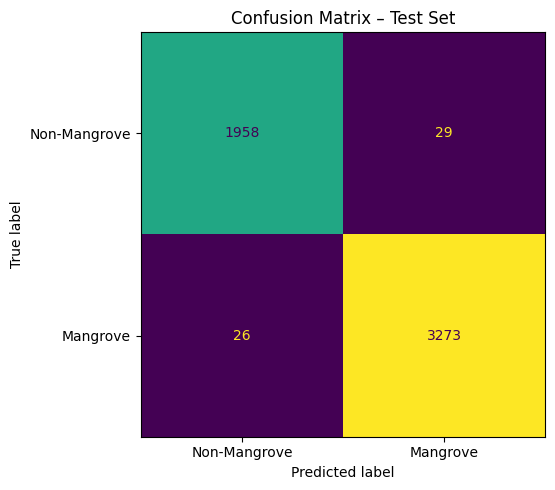

In [16]:
#Evaluating the model on the test set
mangroveClass = ['Non-Mangrove', 'Mangrove']
model.load_state_dict(torch.load(bestMSaved, map_location=GPU))
model.eval()
y_true, y_pred, y_proba = [], [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(GPU)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)
        y_proba.extend(probs[:, 1])
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
y_true  = np.array(y_true)
y_pred  = np.array(y_pred)
y_proba = np.array(y_proba)

print(f'Test Accuracy : {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred, target_names=mangroveClass, digits=4))
#creaing the confusion matrix and visualising it
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=mangroveClass, colorbar=False, ax=ax)
ax.set_title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.show()

In [17]:
def extract_tiles(img: Image.Image,tile_size: int = 512,overlap: int   = 64) -> tuple[torch.Tensor, list]:
    W, H  = img.size
    step  = tile_size - overlap
    tiles, positions = [], []
    for top in range(0, max(H - tile_size + 1, 1), step):
        for left in range(0, max(W - tile_size + 1, 1), step):
            box = (left, top,
                    min(left + tile_size, W),
                    min(top  + tile_size, H))
            tile = img.crop(box)
            if tile.size != (tile_size, tile_size):
                padded = Image.new('RGB', (tile_size, tile_size), (0, 0, 0))
                padded.paste(tile, (0, 0))
                tile = padded
            tiles.append(infer_tf(tile))
            positions.append(box)

    return torch.stack(tiles), positions


def predict_image(image_path: str, tile_size: int  = 512,overlap: int = 64, batch_size: int = 64,confidence_threshold: float = 0.0,auto_classify_threshold: float = 0.7) -> dict:
    model.load_state_dict(torch.load(bestMSaved, map_location=GPU))
    model.eval()
    img = Image.open(image_path).convert('RGB')
    tiles, _  = extract_tiles(img, tile_size, overlap)
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(tiles), batch_size):
            batch  = tiles[i:i + batch_size].to(GPU)
            probs  = torch.softmax(model(batch), dim=1).cpu().numpy()
            if confidence_threshold > 0:
                mask = probs.max(axis=1) >= confidence_threshold
                probs = probs[mask]
            if len(probs):
                all_probs.append(probs)
    if not all_probs:
        return {'prediction': 'Non-Mangrove', 'confidence': 1.0,'probs': [1.0, 0.0], 'n_tiles': len(tiles)}
    avg_probs = np.concatenate(all_probs, axis=0).mean(axis=0)
    predictionIndex = int(avg_probs.argmax())
    confidence = float(avg_probs[predictionIndex])
    prediction = mangroveClass[predictionIndex]
    if prediction == 'Mangrove' and confidence < auto_classify_threshold:
        prediction = 'Non-Mangrove'
        confidence = float(avg_probs[0])
    return {'prediction': prediction,'confidence': confidence,'probs': avg_probs.tolist(),'n_tiles': len(tiles),}

predictionDir = Path(r'C:\Users\FSOS\Music\zow\predict')
imageFiles = [p for p in predictionDir.rglob('*') if p.suffix.lower() in imageType]
if not imageFiles:
    print(f'No images found in {predictionDir}')
else:
    print(f'Predicting on {len(imageFiles):,} images …\n')
    rows = []
    for img_path in tqdm(imageFiles):
        r = predict_image(str(img_path), auto_classify_threshold=0.7)
        rows.append({
            'file': img_path.name,
            'prediction': r['prediction'],
            'confidence': f"{r['confidence']*100:.1f}%",
            'P_non_man': f"{r['probs'][0]:.4f}",
            'P_man': f"{r['probs'][1]:.4f}",
            'n_tiles': r['n_tiles'],
        })

    # Print summary
    print(f"{'File':<40} {'Prediction':<15} {'Confidence':>12}")
    print('-' * 70)
    for row in rows:
        print(f"{row['file']:<40} {row['prediction']:<15} {row['confidence']:>12}")

    counts = Counter(r['prediction'] for r in rows)
    print(f"\nSummary:")
    for cls in mangroveClass:
        n = counts.get(cls, 0)
        print(f"  {cls:<15} {n:>5,} images  ({n/len(rows)*100:.1f}%)")


Predicting on 68 images …



100%|██████████| 68/68 [00:16<00:00,  4.17it/s]

File                                     Prediction        Confidence
----------------------------------------------------------------------
DJI_20260529140016_0001_V.JPG            Mangrove               99.5%
DJI_20260529140018_0002_V.JPG            Mangrove               97.4%
DJI_20260529140020_0003_V.JPG            Mangrove               99.9%
DJI_20260529140021_0004_V.JPG            Mangrove              100.0%
DJI_20260529140023_0005_V.JPG            Mangrove               99.7%
DJI_20260529140025_0006_V.JPG            Mangrove               99.4%
DJI_20260529140027_0007_V.JPG            Mangrove               98.7%
DJI_20260529140029_0008_V.JPG            Mangrove               98.9%
DJI_20260529140031_0009_V.JPG            Mangrove               99.3%
DJI_20260529140033_0010_V.JPG            Mangrove               99.9%
DJI_20260529140035_0011_V.JPG            Mangrove              100.0%
DJI_20260529140036_0012_V.JPG            Mangrove               99.8%
DJI_20260529140038_